# M6 Returns & Risk — End-to-End Pipeline Walkthrough

Runs every stage of the `m6_returns_risk` pipeline directly (the same functions
`src/dags/dag_factory.py` wires into the Airflow DAG), against a real long-format monthly
log-return panel staged at `data/m6_returns_risk/landing/m6_returns_panel.csv` — a representative
15-ticker subset (broad-market ETFs, large-cap tech/financials/energy/healthcare/consumer names)
pulled live via `yfinance` by `scripts/stage_m6_returns_risk_landing.py` (Track 2 of the M6
Competition brief: https://arxiv.org/pdf/2310.13357).

See `docs/superpowers/specs/2026-09-22-m6-returns-risk-design.md` for the design this notebook
exercises stage by stage.

**Stages:** ingest → validate_raw → profile + ADF stationarity report → clean → feature_engineer →
validate_features → train (Random Walk / Mean / ARIMA / cross-sectional GBM) →
evaluate_and_register (cross-sectional rank-IC) → serve.

**Runtime:** a few minutes end to end — this panel is small (~1,400 rows, 15 assets), so no
stage here approaches the runtime concerns `pjm_load_forecast_pipeline.ipynb`'s MSTL/SARIMAX
stages carry at hourly scale.

In [1]:
import os
from pathlib import Path

# Notebooks run with CWD=notebooks/ by default; every pipeline path in this repo
# (data/, config/, reports/) is relative to the repo root.
if not Path("pyproject.toml").exists() and Path("../pyproject.toml").exists():
    os.chdir("..")
print("Working directory:", Path.cwd())

Working directory: /Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6


In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import yaml

from src.ingest import ingest_files
from src.validate import validate_raw_files
from src.profile import profile_raw_files, generate_adf_report
from src.finance.clean_finance import clean_finance_data
from src.finance.features_finance import engineer_finance_features
from src.schemas.features import build_finance_features_schema
from src.finance.train_finance import train_finance_models
from src.finance.evaluate_finance import register_finance_models_to_mlflow
from src.finance.rank_ic import reload_model
from src.finance.serve_finance import forecast_per_asset_model

# src.profile sets matplotlib's backend to "Agg" at import time (headless -
# correct for an Airflow worker, but it silently breaks inline plotting in a
# notebook kernel too, since Agg doesn't route through IPython's display
# hook). Force the inline backend back on, after that import.
%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 4)

CONFIG_DIR = "config/m6_returns_risk"
LANDING_DIR = "data/m6_returns_risk/landing"
RAW_DIR = "data/m6_returns_risk/raw"
INTERIM_DIR = "data/m6_returns_risk/interim"
FEATURES_DIR = "data/m6_returns_risk/features"
REPORTS_DIR = "reports/m6_returns_risk"

# A local, self-contained MLflow store for this notebook's own demo run - NOT the
# docker-compose mlflow-server at localhost:5001. mlflow-server's artifact root
# (/mlflow-artifacts) is bind-mounted and writable inside the Airflow/FastAPI
# containers, but a plain host Python process (this notebook's kernel) can't write
# there, so client-side mlflow.*.log_model() calls against the real server fail with
# "Read-only file system: '/mlflow-artifacts'" outside Docker. A local sqlite +
# local-file store keeps this notebook fully reproducible with no dependency on
# docker-compose being up at all - same pattern pjm_load_forecast_pipeline.ipynb uses.
MLFLOW_TRACKING_URI = f"sqlite:///{Path.cwd() / 'notebooks' / 'm6_returns_risk_demo_mlflow.db'}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("m6_returns_risk_notebook_demo")

RUN_ID = "notebook-demo"  # distinct from Airflow's date-based run_ids, so re-running this
                           # notebook never collides with a real scheduled/manual DAG run
print(f"RUN_ID = {RUN_ID!r}")
print(f"MLflow tracking URI = {MLFLOW_TRACKING_URI}")

/Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


RUN_ID = 'notebook-demo'
MLflow tracking URI = sqlite:////Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6/notebooks/m6_returns_risk_demo_mlflow.db


## Stage 1-2: Ingest & Validate

`ingest_files` copies the landing CSV into a versioned `raw/<run_id>/` directory and writes a
checksummed `manifest.yaml`. `validate_raw_files` then checks it against the pandera-backed rules
in `config/m6_returns_risk/pipeline.yaml` (`Date`/`Ticker`/`log_return` required, `log_return`
bounded to [-1.0, 1.0], min 500 rows).

In [3]:
ingest_result = ingest_files(LANDING_DIR, RAW_DIR, RUN_ID)
print(f"Ingested {ingest_result['file_count']} file(s) -> {ingest_result['manifest_path']}")

validate_result = validate_raw_files(RAW_DIR, RUN_ID, config_dir=CONFIG_DIR)
print(f"Validated: {list(validate_result['validated_files'])}")
print(f"Failed: {validate_result['failed_files']}")

Ingested 1 file(s) -> data/m6_returns_risk/raw/notebook-demo/manifest.yaml
Validated: ['m6_returns_panel.csv']
Failed: []


## Stage 3: Profile + ADF stationarity report

`profile_raw_files` generates the standard ydata-profiling HTML report. `generate_adf_report`
(`src/profile.py`) runs an Augmented Dickey-Fuller test per asset directly on its raw log-return
series — this is requirement #1: confirm return-stationarity and motivate the Random Walk
benchmark. Results are written to both an HTML report and
`reports/m6_returns_risk/notebook-demo_adf_report.yaml` (the same file
`src.finance.evaluate_finance._load_adf_summary` pulls through into the evaluation report).

In [4]:
profile_result = profile_raw_files(RAW_DIR, RUN_ID, reports_dir=REPORTS_DIR, config_dir=CONFIG_DIR)
for fname, info in profile_result["reports"].items():
    print(f"{fname}: {info['rows']:,} rows x {info['columns']} cols -> {info['report_path']}")

adf_result = generate_adf_report(RAW_DIR, RUN_ID, reports_dir=REPORTS_DIR, config_dir=CONFIG_DIR)
adf_df = pd.DataFrame(adf_result["adf_results"]).T.sort_index()
adf_df["is_stationary"] = adf_df["is_stationary"].astype(bool)
print(f"ADF report -> {adf_result['report_path']}")
adf_df

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/8 [00:00<?, ?it/s, Describe variable: Date]

Summarize dataset:   0%|          | 0/8 [00:00<?, ?it/s, Describe variable: log_return]

Summarize dataset:   0%|          | 0/8 [00:00<?, ?it/s, Describe variable: log_return]

  0%|          | 0/3 [00:00<?, ?it/s]

...

Render HTML: 100%|██████████| 1/1 [00:00<00:00, 20.06it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 1900.45it/s]

m6_returns_panel.csv: 1,410 rows x 3 cols -> reports/m6_returns_risk/notebook-demo_m6_returns_panel_profile.html
ADF report -> reports/m6_returns_risk/notebook-demo_adf_report.html


,adf_statistic,p_value,is_stationary,n_obs
AAPL,-8.213881,0.0,True,92
AMZN,-10.981326,0.0,True,93
DIS,-10.289846,0.0,True,93
GOOGL,-10.22681,0.0,True,93
JNJ,-8.770295,0.0,True,92
JPM,-5.067328,0.000016,True,90
KO,-8.87774,0.0,True,92
MSFT,-10.01838,0.0,True,93
PG,-9.130656,0.0,True,92
QQQ,-10.097859,0.0,True,93


In [5]:
from IPython.display import Markdown, display

n_stationary = int(adf_df["is_stationary"].sum())
n_total = len(adf_df)
non_stationary = sorted(adf_df.index[~adf_df["is_stationary"]].tolist())

discussion = (
    f"**Stationarity discussion (real numbers from the ADF run above):** "
    f"{n_stationary}/{n_total} assets' monthly log-returns reject the unit-root null "
    f"hypothesis at p<0.05 (i.e. are stationary). "
    + (
        f"The full 15-asset panel is stationary, consistent with the Efficient Market "
        f"Hypothesis's implication that returns (unlike price levels) should not be "
        f"predictable from their own past values alone — this motivates Random Walk as a "
        f"legitimate baseline for this pipeline, not a naive strawman."
        if n_stationary == n_total else
        f"The non-stationary exception(s) — {', '.join(non_stationary)} — still support the "
        f"same overall conclusion: {n_stationary}/{n_total} is a strong majority, so Random "
        f"Walk remains a legitimate baseline for this panel, with the caveat that a "
        f"month-over-month trend may be present in the named exception(s)."
    )
)
display(Markdown(discussion))

**Stationarity discussion (real numbers from the ADF run above):** 15/15 assets' monthly log-returns reject the unit-root null hypothesis at p<0.05 (i.e. are stationary). The full 15-asset panel is stationary, consistent with the Efficient Market Hypothesis's implication that returns (unlike price levels) should not be predictable from their own past values alone — this motivates Random Walk as a legitimate baseline for this pipeline, not a naive strawman.

## Stage 4: Clean

`clean_finance_data` parses, sorts, dedupes (averaging same-day duplicates, never arbitrarily
discarding one — same reasoning as `pjm_load_forecast`'s DST duplicate handling), reindexes each
asset onto its own complete monthly range, and gap-checks/fills per `config/m6_returns_risk/cleaning.yaml`.
A quick look at a few real assets' raw log-return series after cleaning:

Cleaned: 1,410 rows, 0 duplicates dropped, 0 gap(s) found (0 months filled)


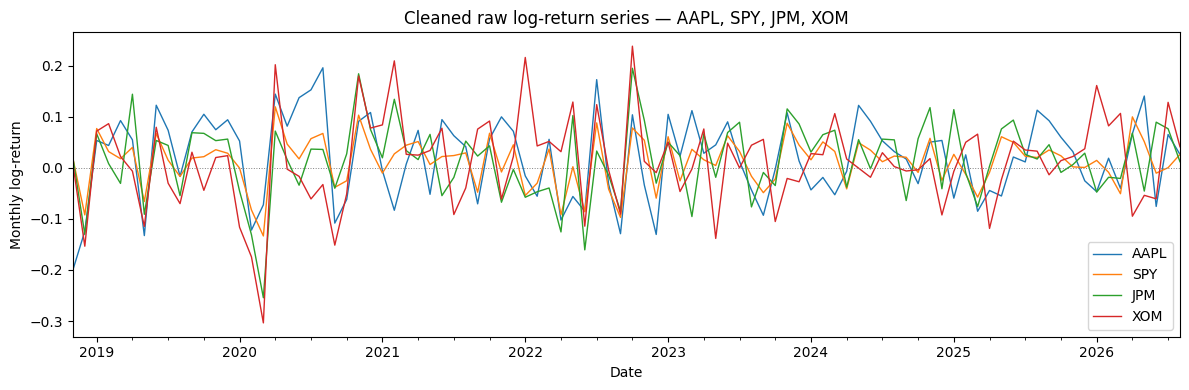

In [6]:
clean_result = clean_finance_data(RAW_DIR, INTERIM_DIR, RUN_ID, config_dir=CONFIG_DIR)
print(f"Cleaned: {clean_result['row_count']:,} rows, "
      f"{clean_result['duplicates_dropped']} duplicates dropped, "
      f"{clean_result['gaps_found']} gap(s) found ({clean_result['gaps_filled_months']} months filled)")

with open(f"{INTERIM_DIR}/{RUN_ID}/manifest.yaml") as f:
    interim_manifest = yaml.safe_load(f)
cleaned_df = pd.read_parquet(interim_manifest["output_path"])
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])

sample_tickers = ["AAPL", "SPY", "JPM", "XOM"]
fig, ax = plt.subplots()
for ticker in sample_tickers:
    series = cleaned_df[cleaned_df["Ticker"] == ticker].set_index("Date")["log_return"]
    series.plot(ax=ax, label=ticker, linewidth=1)
ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
ax.set_ylabel("Monthly log-return")
ax.set_title(f"Cleaned raw log-return series — {', '.join(sample_tickers)}")
ax.legend()
plt.tight_layout()
plt.show()

## Stage 5: Feature engineer

`engineer_finance_features` builds the cross-sectional GBM's small lag/trailing-volatility
feature set per asset (never across a Ticker boundary), label-encodes Ticker, replaces Date with
a monthly ordinal, and splits each asset chronologically (`train_test_split` from
`pipeline.yaml`, most-recent slice held out as test — never a random split).

In [7]:
features_result = engineer_finance_features(INTERIM_DIR, FEATURES_DIR, RUN_ID, config_dir=CONFIG_DIR)
print(f"Train shape: {features_result['train_shape']}, Test shape: {features_result['test_shape']}")
print(f"Feature count: {features_result['feature_count']}, rows dropped to lag/vol warm-up: {features_result['rows_dropped_warmup']}")

train_df = pd.read_parquet(features_result["train_path"])
train_df.head()

Train shape: (975, 5), Test shape: (255, 5)
Feature count: 3, rows dropped to lag/vol warm-up: 180


,log_return,lag_1_return,trailing_12m_vol,ticker_encoded,date_ordinal
0,0.074694,0.104976,0.106324,0,598
1,0.094204,0.074694,0.083730,0,599
2,0.052602,0.094204,0.068366,0,600
3,-0.121831,0.052602,0.068366,0,601
4,-0.072314,-0.121831,0.085061,0,602


## Stage 6: Validate features

`build_finance_features_schema(target_col).validate(...)` against the real `train.parquet` —
mirrors `dag_factory.py`'s `validate_features_wrapper` (row-count floor, all-numeric guard, then
the pandera schema).

In [8]:
assert len(train_df) >= 100, "train set too small"
non_numeric = train_df.select_dtypes(exclude="number").columns.tolist()
assert not non_numeric, f"non-numeric columns: {non_numeric}"
schema = build_finance_features_schema("log_return")
validated = schema.validate(train_df)
print(f"validate_features passed: {len(validated):,} rows, all-numeric, schema-valid")

validate_features passed: 975 rows, all-numeric, schema-valid


## Stage 7: Train — Random Walk, Mean, ARIMA, cross-sectional GBM

Random Walk/Mean/ARIMA are fit per asset (one MLflow run per (model_type, asset) pair);
cross-sectional GBM is fit once across the whole stacked panel. Each logs its training-period
error standard deviation (the risk-analysis "how certain is your model?" figure) to MLflow.

In [9]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
train_result = train_finance_models(
    FEATURES_DIR, RUN_ID, config_dir=CONFIG_DIR, mlflow_tracking_uri=MLFLOW_TRACKING_URI,
)
print(f"{len(train_result['models'])} (model_type, asset) runs trained")

train_summary = pd.DataFrame(train_result["models"]).T
train_summary["train_error_std"] = train_summary["train_error_std"].astype(float)
type_summary = train_summary.groupby("model_type")["train_error_std"].agg(["mean", "std", "count"])
type_summary

2026/09/23 22:20:46 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6


2026/09/23 22:20:46 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/09/23 22:20:46 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6


2026/09/23 22:20:46 INFO mlflow.utils.environment: Detected uv project at /Users/danielguo/Development/ai_learning_projects/ml_pipeline/.claude/worktrees/m6-returns-risk-plan-6. Attempting to export requirements via 'uv export'.


2026/09/23 22:20:46 INFO mlflow.utils.uv_utils: Exported 258 dependencies via uv


...

2026/09/23 22:20:55 INFO mlflow.utils.uv_utils: Exported 258 dependencies via uv


2026/09/23 22:20:55 INFO mlflow.utils.environment: Successfully exported 258 requirements from uv project. Skipping package capture based inference.


2026/09/23 22:20:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


46 (model_type, asset) runs trained


,mean,std,count
model_type,,,
arima,0.069352,0.017115,15
cross_sectional_gbm,0.066378,NaN,1
mean,0.069760,0.017100,15
random_walk,0.069760,0.017100,15


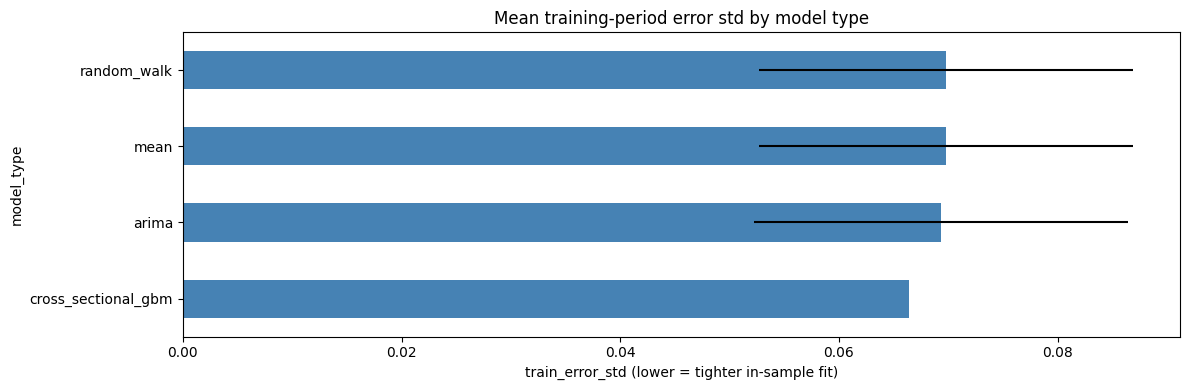

In [10]:
type_summary["mean"].sort_values().plot.barh(xerr=type_summary["std"].fillna(0), color="steelblue")
plt.xlabel("train_error_std (lower = tighter in-sample fit)")
plt.title("Mean training-period error std by model type")
plt.tight_layout()
plt.show()

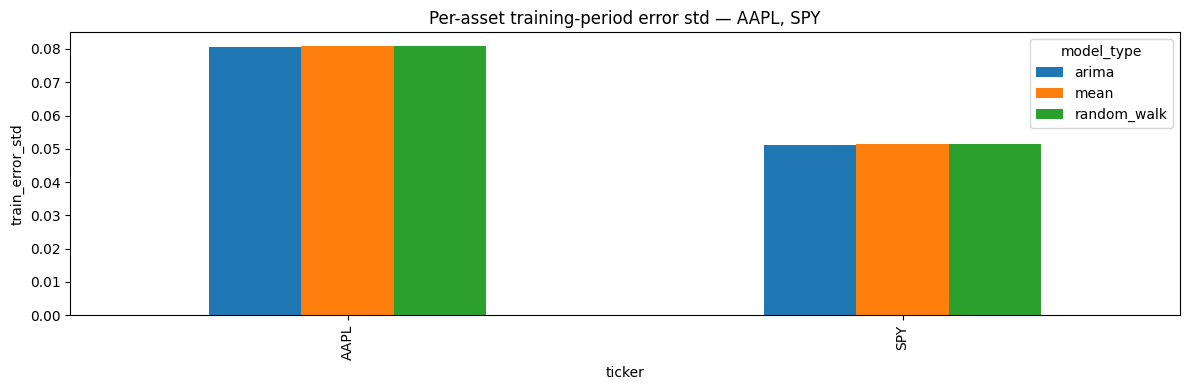

model_type,arima,mean,random_walk
ticker,,,
AAPL,0.080601,0.080938,0.080938
SPY,0.050989,0.051394,0.051394


In [11]:
# A couple of sample assets, per model type
sample_assets = ["AAPL", "SPY"]
per_asset_sample = train_summary[train_summary.get("ticker", pd.Series(dtype=object)).isin(sample_assets)]
pivot = per_asset_sample.pivot_table(index="ticker", columns="model_type", values="train_error_std", aggfunc="mean")
pivot.plot.bar()
plt.ylabel("train_error_std")
plt.title(f"Per-asset training-period error std — {', '.join(sample_assets)}")
plt.tight_layout()
plt.show()
pivot

## Stage 8: Evaluate & Register to MLflow

Each trained (model_type, asset) model is reloaded from MLflow and scored against the held-out
**test** period. Predictions are assembled into a (month, ticker, predicted, actual) long table
per model type, and cross-sectional Spearman rank correlation (Information Coefficient) is
averaged across test months — directly operationalizing the rank-driven long/short framing
(requirement #4): a hedge fund cares more about which asset will do *better* than another than
about the exact predicted return. Passing models register to MLflow `Staging` (never
auto-promoted to `Production`); the run champion is the model TYPE with the highest rank-IC.

In [12]:
run_ids = {name: info["mlflow_run_id"] for name, info in train_result["models"].items()}

register_result = register_finance_models_to_mlflow(
    mlflow_tracking_uri=MLFLOW_TRACKING_URI, mlflow_run_ids=run_ids, config_dir=CONFIG_DIR,
    run_id=RUN_ID, reports_dir=REPORTS_DIR, features_dir=FEATURES_DIR,
)
print(f"{len(register_result['registered_models'])} (model_type, asset) runs registered to Staging")

with open(f"{REPORTS_DIR}/{RUN_ID}_evaluation.yaml") as f:
    evaluation_report = yaml.safe_load(f)

ic_leaderboard = pd.Series(evaluation_report["ic_leaderboard"], name="rank_ic").sort_values(ascending=False)
error_std_leaderboard = pd.Series(evaluation_report["error_std_leaderboard"], name="error_std")
leaderboard = pd.concat([ic_leaderboard, error_std_leaderboard], axis=1)
leaderboard

Registered model 'm6_returns_risk_random_walk_AAPL' already exists. Creating a new version of this model...


2026/09/23 22:20:56 WARNING mlflow.tracking._model_registry.fluent: Run with id e50b4ac0e3344f1a9717d6beda7c1e6a has no artifacts at artifact path 'model', registering model based on models:/m-bbe9ccd05b0a48f29c220a75ea627185 instead


Created version '2' of model 'm6_returns_risk_random_walk_AAPL'.



Registered model 'm6_returns_risk_random_walk_AMZN' already exists. Creating a new version of this model...


2026/09/23 22:20:56 WARNING mlflow.tracking._model_registry.fluent: Run with id a21ee77488e1454eacf1f182a22aaa1d has no artifacts at artifact path 'model', registering model based on models:/m-91a17a3f125d40828a1b9ed0c1f40785 instead


...

Created version '2' of model 'm6_returns_risk_arima_XOM'.


Registered model 'm6_returns_risk_cross_sectional_gbm' already exists. Creating a new version of this model...
2026/09/23 22:21:03 WARNING mlflow.tracking._model_registry.fluent: Run with id e86c6874daaf4a9a9d5666b36b17129b has no artifacts at artifact path 'model', registering model based on models:/m-409fe523aa3644249f53b3f7f7ec8256 instead


Created version '2' of model 'm6_returns_risk_cross_sectional_gbm'.


46 (model_type, asset) runs registered to Staging


,rank_ic,error_std
mean,0.092437,0.071604
arima,0.086134,0.071622
cross_sectional_gbm,0.003300,0.077988
random_walk,NaN,0.071604


`random_walk`'s `rank_ic` above is `NaN`, not zero: it predicts an identical value for
every asset in a given month, so there is no cross-sectional dispersion to rank and Spearman
correlation has no defined value. It is therefore structurally excluded from the
champion-metric comparison, though its `error_std` remains directly comparable to the other
model types.

In [13]:
champion = evaluation_report["run_champion_type"]
print(f"Run champion (model type): {champion} (by {evaluation_report['champion_metric']})")
print()
print(evaluation_report["shrinkage_discussion"])
print()
print(evaluation_report["error_std_note"])
print()
print(evaluation_report["scoring_methodology_note"])

Run champion (model type): mean (by rank_ic)

Mean (IC=0.0924) matched or outperformed ARIMA (IC=0.0861) in this run - consistent with the shrinkage principle: on noisy financial returns, a simple historical average often generalizes better than a fitted autoregressive model, whose extra parameters mostly capture noise.

error_std_leaderboard measures forecast-error dispersion (Plan 3's risk-analysis figure), not model quality - it is shift-invariant, so models that predict a constant (e.g. random_walk and mean with window=null) can produce numerically identical values despite being different models. Use ic_leaderboard, not this field, to compare model quality.

random_walk/mean/arima are scored with a STATIC multi-step forecast (fitted once, forecasting the entire test horizon from the train boundary); cross_sectional_gbm is scored with FRESH realized features at every test month (an effectively 1-step-ahead information set). The two are not a strictly apples-to-apples comparison - th

## Stage 9: Live serving demo

Reloads one registered per-asset model directly from this notebook's MLflow store
(`src.finance.rank_ic.reload_model`) and produces a real point forecast
(`src.finance.serve_finance.forecast_per_asset_model`) — mirrors the integration test's serving
smoke test and the live `GET /predict/finance-return` endpoint's per-asset code path in
`src/serve.py`.

In [14]:
champion_type = evaluation_report["run_champion_type"]
per_asset_name = None
if champion_type != "cross_sectional_gbm":
    per_asset_name = next(
        (name for name, info in evaluation_report["models"].items()
         if info.get("status") == "registered" and info.get("model_type") == champion_type),
        None,
    )
if per_asset_name is None:
    # Champion type is cross_sectional_gbm (not usable for this multi-step demo) or has no
    # registered per-asset model — fall back to the first non-GBM registered model.
    per_asset_name = next(
        name for name, info in evaluation_report["models"].items()
        if info.get("status") == "registered" and info.get("model_type") != "cross_sectional_gbm"
    )
per_asset_info = evaluation_report["models"][per_asset_name]
per_asset_run_id = run_ids[per_asset_name]
model_type = per_asset_info["model_type"]

loaded_model = reload_model(model_type, per_asset_run_id, MLFLOW_TRACKING_URI)
forecast = forecast_per_asset_model(loaded_model, model_type, horizon_months=3)

print(f"Serving demo: {per_asset_name} (model_type={model_type})")
print(f"3-month-ahead point forecast (log-return): {forecast}")
print(f"test_error_std (from the evaluation report above): {per_asset_info['test_error_std']:.6f}")

Serving demo: m6_returns_risk_mean_AAPL (model_type=mean)
3-month-ahead point forecast (log-return): [0.02012551 0.02012551 0.02012551]
test_error_std (from the evaluation report above): 0.063030


## Known limitations

Named honestly, not glossed over:

1. **Forecast horizon is relative to the training cutoff, not "today".** `random_walk`/`mean`/
   `arima` forecast `horizon_months` steps forward from wherever their own training data ends
   (this run's `RUN_ID = "notebook-demo"` training cutoff), not from the notebook's execution
   date. A forecast made today from a model trained on data through last month is *not* the same
   thing as "today's forecast" unless the model is retrained on fresh data first.
2. **`cross_sectional_gbm` live serving supports `horizon_months=1` only.** Its feature set
   (lags/trailing volatility) is built from realized history one step at a time —
   `load_latest_asset_features` constructs a genuine next-period row, but there is no recursive
   multi-step path (an explicit, deliberate out-of-scope decision, not an oversight).
3. **The ~15-ticker subset above is representative, not the full M6 100-asset universe.** It
   spans broad-market ETFs and large-cap names across several sectors, chosen to avoid a large
   rate-limited `yfinance` fetch surface and delisting/gap handling for this POC's scope — real
   market data, but a small, liquid slice of it, not the complete M6 Competition panel.

## Summary

One row per model type: mean training-period error std, mean test-period error std, rank-IC, and
whether it was this run's champion.

In [15]:
summary_rows = []
for model_type in sorted(set(train_summary["model_type"])):
    summary_rows.append({
        "model_type": model_type,
        "train_error_std": type_summary.loc[model_type, "mean"] if model_type in type_summary.index else float("nan"),
        "test_error_std": evaluation_report["error_std_leaderboard"].get(model_type, float("nan")),
        "rank_ic": evaluation_report["ic_leaderboard"].get(model_type, float("nan")),
        "run_champion": model_type == champion,
    })
summary_df = pd.DataFrame(summary_rows).set_index("model_type").sort_values("rank_ic", ascending=False)
summary_df

,train_error_std,test_error_std,rank_ic,run_champion
model_type,,,,
mean,0.069760,0.071604,0.092437,True
arima,0.069352,0.071622,0.086134,False
cross_sectional_gbm,0.066378,0.077988,0.003300,False
random_walk,0.069760,0.071604,NaN,False
